# Домашнее задание. Свёрточные сети

Здесь вам предстоит построить и обучить свою первую свёрточную сеть для классификации изображений на данных CIFAR10.

In [97]:
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm
import numpy as np
from sklearn.model_selection import train_test_split

import keras.losses
import keras.optimizers
import keras.metrics

## Данные

CIFAR10
* 60000 RGB изображений размером 32x32x3
* 10 классов: самолёты, собаки, рыбы и т.п.

<img src="https://www.samyzaf.com/ML/cifar10/cifar1.jpg" style="width:60%">

Загрузите данные, разделите их на обучающую и тестовую выборки. Размер тестовой выборки должен быть $10^4$.

In [98]:
from keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10**4, random_state=42)

class_names = np.array(['airplane','automobile ','bird ','cat ','deer ','dog ','frog ','horse ','ship ','truck'])

print (X_train.shape,y_train.shape)

(40000, 32, 32, 3) (40000, 1)


Прежде чем приступать к основной работе, стоит убедиться что загруженно именно то, что требовалось:

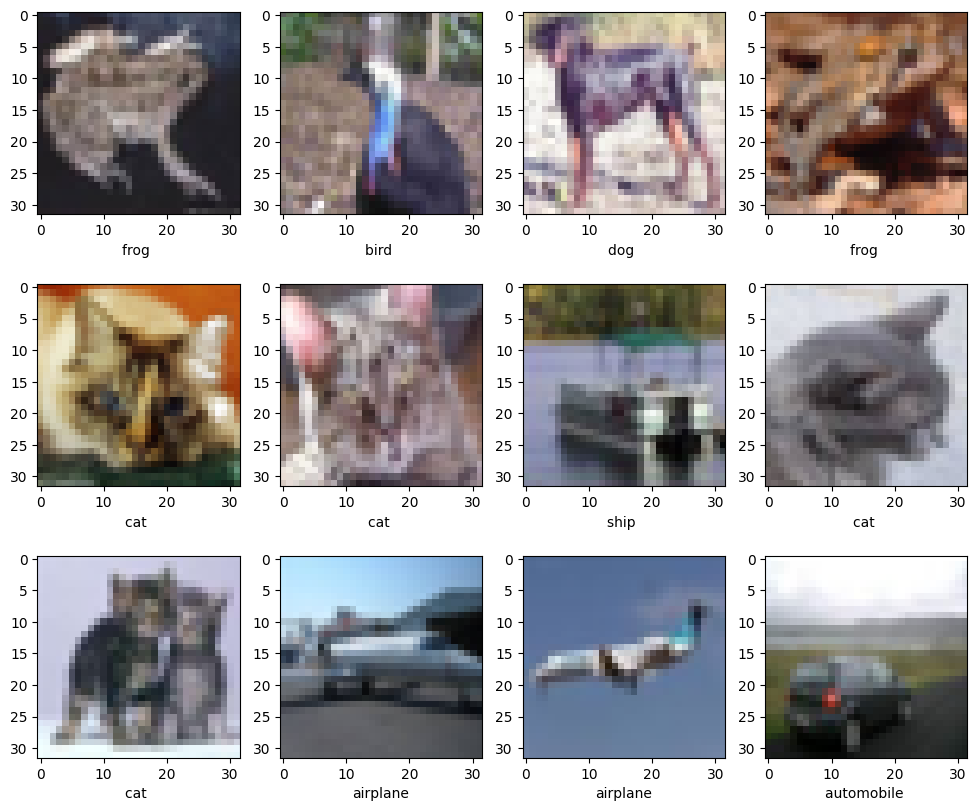

In [99]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xlabel(class_names[y_train[i, 0]])
    plt.imshow(X_train[i])

## Подготовка данных

Сейчас каждый пиксель изображения закодирован тройкой чисел (RGB) __от 0 до 255__. Однако лучше себя показывает подход, где значения входов нейросети распределены недалеко от 0.

Давайте приведём все данные в диапазон __`[0, 1]`__ — просто разделим на соответствующий коэффициент:

In [100]:
X_train = X_train / 255
X_val = X_val / 255
X_test = X_test / 255

Исполните код ниже для проверки, что все выполнено корректно.

In [101]:
assert np.shape(X_train) == (40000, 32, 32, 3), "data shape should not change"
assert 0.9 <= max(map(np.max, (X_train, X_val, X_test))) <= 1.05
assert 0.0 <= min(map(np.min, (X_train, X_val, X_test))) <= 0.1
assert len(np.unique(X_test / 255.)) > 10, "make sure you casted data to float type"

## Архитектура сети

Для начала реализуйте простую нейросеть:
1. принимает на вход картинки размера 32 x 32 x 3;
2. вытягивает их в вектор (`keras.layers.Flatten`);
3. пропускает через 1 или 2 полносвязных слоя;
4. выходной слой отдает вероятности принадлежности к каждому из 10 классов.

Создайте полносвязную сеть:

In [102]:
import keras
from keras import layers as L
from keras import backend as K

In [103]:
model = tf.keras.models.Sequential([
        # Входной слой это тензор, который должен иметь размерность наших входных данных, т.е. картинки
        tf.keras.layers.Dense(32, activation='relu', input_shape=X_train.shape[1:]),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')

])

In [104]:
dummy_pred = model.predict(X_train[:20])
assert dummy_pred.shape == (20, 10)
assert np.allclose(dummy_pred.sum(-1), 1)
print("Успех!")

1/1 [==============================] - 0s 65ms/step
Успех!


## Обучение сети

**Задание 1.1 (обязательно)** Будем минимизировать многоклассовую кроссэкнропию с помощью __sgd__. Вам нужно получить сеть, которая достигнет __не менее 45%__ __accuracy__ на тестовых данных.

__Важно:__ поскольку в y_train лежат номера классов, Керасу нужно либо указать sparse функции потерь и метрики оценки качества классификации (`sparse_categorical_crossentropy` и `sparse_categorical_accuracy`), либо конвертировать метки в one-hot формат.

### Полезные советы
* `model.compile` позволяет указать, какие метрики вы хотите вычислять.
* В `model.fit` можно передать валидационную выборку (`validation_data=[X_val, y_val]`), для отслеживания прогресса на ней. Также рекомендуем сохранять результаты в [tensorboard](https://keras.io/callbacks/#tensorboard) или [wandb](https://docs.wandb.ai/integrations/jupyter). **Важно: логи tensorboard не получится без боли посмотреть через colab.** Workaround: скачать логи и запустить tensorboard локально или помучаться [с этим](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).
* По умолчанию сеть учится 1 эпоху. Совсем не факт, что вам этого хватит. Число эпох можно настроить в методе `fit` (`epochs`).
* Ещё у Кераса есть много [полезных callback-ов](https://keras.io/callbacks/), которые можно попробовать. Например, автоматическая остановка или подбор скорости обучения.

In [105]:
y_train, y_val = (keras.utils.to_categorical(y) for y in (y_train, y_val))

In [106]:
callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='./checkpoints/model.{epoch:02d}-{val_loss:.2f}.h5'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs/simple'),
             tf.keras.callbacks.EarlyStopping(patience=5)]

In [22]:
model.compile(optimizer = keras.optimizers.SGD(), loss=keras.losses.CategoricalCrossentropy())
model.fit(X_train, y_train, batch_size=16, epochs=3, callbacks=callbacks, validation_data=[X_val, y_val])

Epoch 1/3
2500/2500 [==============================] - 15s 6ms/step - loss: 1.9452 - val_loss: 1.7513
Epoch 2/3
2500/2500 [==============================] - 14s 6ms/step - loss: 1.6801 - val_loss: 1.6051
Epoch 3/3
2500/2500 [==============================] - 16s 6ms/step - loss: 1.5624 - val_loss: 1.5449


А теперь можно проверить качество вашей сети, выполнив код ниже:

In [23]:
from sklearn.metrics import accuracy_score

predict_x=model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
assert test_acc > 0.45, "Not good enough. Back to the drawing board :)"
print(" Not bad!")

313/313 [==============================] - 1s 3ms/step

 Test_acc = 0.4543
 Not bad!


## Карманная сверточная сеть

**Задание 1.2 (обязательно)** Реализуйте небольшую свёрточную сеть. Совсем небольшую:
1. Входной слой
2. Свёртка 3x3 с 10 фильтрами
3. Нелинейность на ваш вкус
4. Max-pooling 2x2
5. Вытягиваем оставшееся в вектор (Flatten)
6. Полносвязный слой на 100 нейронов
7. Нелинейность на ваш вкус
8. Выходной полносвязный слой с softmax

Обучите её так же, как и предыдущую сеть. Если всё хорошо, у вас получится accuracy не меньше __50%__.

In [107]:
new_model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(filters=10, padding='same', kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
])

In [108]:
new_callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='new_model.{epoch:02d}-{val_loss:.2f}.h5'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs/simple_conv'),
             tf.keras.callbacks.EarlyStopping(patience=3)]

In [109]:
new_model.compile(optimizer = keras.optimizers.SGD(), loss=keras.losses.CategoricalCrossentropy())
new_model.fit(X_train, y_train, batch_size=16, epochs=32, callbacks=new_callbacks, validation_split=0.2)

Epoch 1/32
2000/2000 [==============================] - 12s 6ms/step - loss: 1.9209 - val_loss: 1.7004
Epoch 2/32
2000/2000 [==============================] - 11s 6ms/step - loss: 1.6135 - val_loss: 1.5292
Epoch 3/32
2000/2000 [==============================] - 12s 6ms/step - loss: 1.4856 - val_loss: 1.4667
Epoch 4/32
2000/2000 [==============================] - 13s 7ms/step - loss: 1.4030 - val_loss: 1.4430
Epoch 5/32
2000/2000 [==============================] - 11s 6ms/step - loss: 1.3321 - val_loss: 1.3673
Epoch 6/32
2000/2000 [==============================] - 12s 6ms/step - loss: 1.2618 - val_loss: 1.3100
Epoch 7/32
2000/2000 [==============================] - 11s 5ms/step - loss: 1.1973 - val_loss: 1.2554
Epoch 8/32
2000/2000 [==============================] - 11s 6ms/step - loss: 1.1438 - val_loss: 1.2422
Epoch 9/32
2000/2000 [==============================] - 11s 6ms/step - loss: 1.0953 - val_loss: 1.2347
Epoch 10/32
2000/2000 [==============================] - 11s 6ms/step - l

Давайте посмотрим, смогла ли карманная сверточная сеть побить заданный порог по качеству:

In [110]:
predict_x = new_model.predict(X_test)
classes_x = np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
#assert test_acc > 0.50, "Not good enough. Back to the drawing board :)"
print(" Not bad!")

313/313 [==============================] - 1s 3ms/step

 Test_acc = 0.5916
 Not bad!


## Учимся учить

А теперь научимся сравнивать кривые обучения моделей — зависимости значения accuracy от количества итераций.

Вам потребуется реализовать _экспериментальный стенд_ — вспомогательный код, в который вы сможете подать несколько архитектур и методов обучения, чтобы он их обучил и вывел графики кривых обучения. Это можно сделать с помощью `keras.callbacks` — `TensorBoard` или `History`.

Будьте морально готовы, что на обучение уйдёт _много времени_. Даже если вы ограничитесь 10 эпохами. Пока идёт обучение, вы можете переключиться на другие задания или заняться чем-нибудь приятным: поспать, например.

**Задание 1.3 (опционально)** Попробуйте использовать различные методы оптимизации (sgd, momentum, adam) с параметрами по умолчанию. Какой из методов работает лучше?

Для удобства напишем класс Evaluator, который принимает в себя дикты виды {имя_оптимайзера: инстанс}, {имя модели: инстанс} и обучает всевозможные комбинации моделей с оптимайзерами при помощи метода fit (попутно записывая логи отдельно для каждой модели). Также пригодится метод evaluate для отображения итоговых скоров.

Пользоваться классом не обязательно. По умолчанию класс использует tensorboard. Если вы выше использовали wandb -- советуем дописать callback.

In [26]:
class Evaluator(list):
    def __init__(self, models, optimizers, loss=keras.losses.categorical_crossentropy,
                 metrics=[keras.metrics.categorical_accuracy]):
        '''
            models: dict {name: model}
            optimizers: dict {name: optimizer}
        '''
        
        assert isinstance(models, dict), "Invalid input. Dictionary of models expected in 'models'"
        assert len(models) > 0, "Invalid input. One or more models expected"
        assert isinstance(optimizers, dict), "Invalid input. Dictionary of optimizers expected in 'optimizers'"
        assert len(optimizers) > 0, "Invalid input. One or more optimizers expected"
        
        super().__init__([(model_name, keras.models.clone_model(model), optimizer_name, optimizer)
                          for model_name, model in models.items()
                          for optimizer_name, optimizer in optimizers.items()])
        for _, model, _, optimizer in self:
            model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def fit(self, X, y, validation_data=(), max_epochs=100, verbose=0, callbacks=[], batch_size=32):
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in self:
            model.fit(X, y, validation_data=validation_data or None, epochs=max_epochs, verbose=verbose,
                      batch_size=batch_size, callbacks=callbacks + [keras.callbacks.TensorBoard(
                          log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def fit_generator(self, X, y, validation_data=(), max_epochs=100, verbose=1, callbacks=[], batch_size=32):
        datagen = keras.preprocessing.image.ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True
        )
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in self:
            model.fit_generator(datagen.flow(X, y, batch_size=batch_size), epochs=max_epochs,
                validation_data=validation_data or None, verbose=verbose,
                callbacks=callbacks + [keras.callbacks.TensorBoard(
                    log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def evaluate(self, X, y, metric):
        for model_name, model, optimizer_name, _ in self:
            print('Final score of {}_{} is {}'.format(model_name, optimizer_name,
                  metric(y_test, model.predict(X_test).argmax(axis=1))))

In [17]:
# Модель с 1 сверточным слоем с 10 фильтрами размера 3x3 и одним полносвязным слоем размера 100
conv_1conv10_33_1dense100_model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(filters=10, padding='same', kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
])

adam_opt = keras.optimizers.Adam()
sgd_opt = keras.optimizers.SGD()
adagrad_opt = keras.optimizers.Adagrad()
adam_opt_lr_0_01 = keras.optimizers.Adam(learning_rate=0.01)
optimizers = {"Adam": adam_opt, "SGD": sgd_opt, "Adagrad": adagrad_opt, "Adam_0_01": adam_opt_lr_0_01}
models = {"conv_1conv10_33_1dense100_model": conv_1conv10_33_1dense100_model}

In [37]:
optimizers_analysis_callbacks = [tf.keras.callbacks.EarlyStopping(patience=3)]
evaluator = Evaluator(models=models, optimizers=optimizers)
evaluator.fit(X_train, y_train, validation_data=(X_val, y_val), max_epochs=50, callbacks=optimizers_analysis_callbacks)
evaluator.evaluate(X_test, y_test, accuracy_score)

313/313 [==============================] - 1s 4ms/step
Final score of conv_1conv10_33_1dense100_model_Adam is 0.5979
313/313 [==============================] - 1s 3ms/step
Final score of conv_1conv10_33_1dense100_model_SGD is 0.6041
313/313 [==============================] - 1s 4ms/step
Final score of conv_1conv10_33_1dense100_model_Adagrad is 0.5224
313/313 [==============================] - 1s 3ms/step
Final score of conv_1conv10_33_1dense100_model_Adam_0_01 is 0.1


### Результаты исследования оптимизаторов
Выполнил обучение модели для 4 оптимизаторов: Adam, Adagrad, SGD, Adam (скоростью обучения 0.01, что выше умолчательной 0.001). 
Итого:
- Выполнял с максимумо 50 эпох, а не 100, как в задании. Но и эти не 50 не дошли до конца, например Adam прошел 6 эпох, а SGD 22. Списываю это на EarlyStopping, хотя по графикам не совсем понятно, validation, оценивающий loss выравнивается, но не то чтобы совсем. Единственным кто дошел до конца является Adagrad.
- Во всех моделях наблюдаю отклонение валидационной оценки от той, которая получается на тренировочных данных с увеличением эпох. Пока не понимаю, является ли это следствием переобучения или недостаточных возможностей такой простой модели. Или простота этой модели ведет к переобучению =)
- Лучше всего себя показал SGD, правда Adagrad как будто еще имеет возможности к улучшению, поскольку остановился не по EarlyStopping. Результат accuracy_score равен 0.6041
- Adam с learning rate равным 0.01 самый худший вариант. По графикам валидации видно, что эта скорость обучения высокая, график пилообразный.

Непосредственно результаты:
- Final score of conv_1conv10_33_1dense100_model_Adam is 0.5979
- Final score of conv_1conv10_33_1dense100_model_SGD is 0.6041
- Final score of conv_1conv10_33_1dense100_model_Adagrad is 0.5224
- Final score of conv_1conv10_33_1dense100_model_Adam_0_01 is 0.5154


![Результат функции потерь при тестировании оптимизаторов](img/optimizators_loss_epoch.png)
![Результат классификации при тестировании оптимизаторов](img/optimizators_cat_epoch.png)

**Задание 1.4 (опционально)** Добавьте нормализацию по батчу (`BatchNormalization`) между свёрткой и активацией. Попробуйте использовать несколько нормализаций — в свёрточных и полносвязных слоях.

Для удобства реализуем класс Models, который по сути будет являться списком моделей с двумя методами: add (добавить слой ко всем моделям) и add_create (создать новую модель на основе базовой с дополнительным слоем). Пользоваться им необязательно, но вдруг :)

In [15]:
from collections import OrderedDict

class Models(OrderedDict):
    def __init__(self, models):
        if not isinstance(models, dict):
            models = OrderedDict({'base_model': models})
        super().__init__(models)

    def add(self, layer):
        for name, model in self.items():
            model.add(layer)

    def add_create(self, name, layer):
        base_model = next(iter(self.items()))[1]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

    def add_update(self, name, layer):
        base_model = self[next(reversed(self))]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

# Example of usage
# models = Models(keras.Sequential())
# models.add(L.InputLayer(input_shape=(32, 32, 3)))
# models.add(L.Convolution2D(filters=10, kernel_size=(3, 3)))
# models.add(L.MaxPooling2D())
# models.add_create('conv_batchnorm', L.BatchNormalization())
# models.add(L.Activation('relu'))
# ...

In [41]:
# Модель с 1 сверточным слоем с 10 фильтрами размера 3x3 и одним полносвязным слоем размера 100 и нормализацией
conv_1conv10_33_1dense100_norm_model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(filters=10, padding='same', kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Flatten(),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
])

conv_1conv10_33_1dense100_norm2_model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(filters=10, padding='same', kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dense(10, activation='softmax')
])

optimizers = {"SGD": sgd_opt}
models = {"conv_1conv10_33_1dense100_norm_model": conv_1conv10_33_1dense100_norm_model, 
          "conv_1conv10_33_1dense100_norm2_model": conv_1conv10_33_1dense100_norm2_model}

batchnorm_analysis_callbacks = [tf.keras.callbacks.EarlyStopping(patience=3)]
evaluator = Evaluator(models=models, optimizers=optimizers)
evaluator.fit(X_train, y_train, validation_data=(X_val, y_val), max_epochs=50, callbacks=batchnorm_analysis_callbacks)
evaluator.evaluate(X_test, y_test, accuracy_score)

313/313 [==============================] - 1s 4ms/step
Final score of conv_1conv10_33_1dense100_norm_model_SGD is 0.5933
313/313 [==============================] - 1s 4ms/step
Final score of conv_1conv10_33_1dense100_norm2_model_SGD is 0.6094


### Результаты батч-нормализации
- Результаты не сильно лучше, чем без нормализации. Ошибка падает быстрее, чем без нормализации, причем с применением двух слоев нормализации скорость падения ошибки немного больше, чем с одним слоем.
- При использовании батч-нормализации обучение останавливается заметно раньше, т.е. обучение проходит меньше эпох прежде, чем достигает плато на валидационной выборке.

Непосредственно результаты:
- Final score of conv_1conv10_33_1dense100_norm_model_SGD is 0.5933
- Final score of conv_1conv10_33_1dense100_norm2_model_SGD is 0.6094

![Результат функции потерь при тестировании оптимизаторов](img/normalization_loss_epoch.png)
![Результат классификации при тестировании оптимизаторов](img/normalization_cat_epoch.png)

**Задание 1.5 (опционально)** Посмотрите на batch_size (параметр model.fit) - при большем батче модель будет быстрее проходить эпохи, но с совсем огромным батчом вам потребуется больше эпох для сходимости (т.к. сеть делает меньше шагов за одну эпоху).
Найдите такое значение, при котором модель быстрее достигает точности 55%. **Hint**: используйте early stopping callback.

In [16]:
# Взято с SO
# https://stackoverflow.com/questions/43178668/record-the-computation-time-for-each-epoch-in-keras-during-model-fit
import time

class TimeHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

    def total_time(self):
        return sum(self.times)


In [ ]:
# Модель с 1 сверточным слоем с 10 фильтрами размера 3x3 и одним полносвязным слоем размера 100 и нормализацией
conv_1conv10_33_1dense100_batch64_model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(filters=10, padding='same', kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dense(10, activation='softmax')
])

optimizers = {"SGD": sgd_opt}
models = {"conv_1conv10_33_1dense100_batch64_model": conv_1conv10_33_1dense100_batch64_model}

time_history = TimeHistory()
batchsize_analysis_callbacks = [tf.keras.callbacks.EarlyStopping(patience=3), time_history]
evaluator = Evaluator(models=models, optimizers=optimizers)
evaluator.fit(X_train, y_train, validation_data=(X_val, y_val), max_epochs=50, callbacks=batchsize_analysis_callbacks, batch_size=64)
evaluator.evaluate(X_test, y_test, accuracy_score)
print("Learning time {}".format(time_history.total_time()))

313/313 [==============================] - 2s 5ms/step
Final score of conv_1conv10_33_1dense100_batch256_model_SGD is 0.5873
Learning time 202.50755381584167


: 

### Результаты исследования размера батча
Cамый быстрый размер батча, который позволяет достичь точности 55% - 64

Final score of conv_1conv10_33_1dense100_batch256_model_SGD is 0.4494
Learning time 101.77083849906921

Final score of conv_1conv10_33_1dense100_batch128_model_SGD is 0.4858
Learning time 96.8796956539154

Final score of conv_1conv10_33_1dense100_batch64_model_SGD is 0.5801
Learning time 133.22061705589294

Final score of conv_1conv10_33_1dense100_batch32_model_SGD is 0.5873
Learning time 202.50755381584167

**Задание 1.6 (опционально)** Попробуйте найти такую комбинацию метода обучения и нормализации, при которой сеть имеет наилучшую кривую обучения. Поясните, что вы понимаете под "наилучшей" кривой обучения.

Исходя из графиков делаю вывод, что лучшая комбинация метода обучения и нормализации - это SGD и нормализация после каждого слоя, сверточного и полносвязного. Под кривой обучения я понимаю кривую уменьшения значения функции потерь в зависимости от эпохи - чем быстрее уменьшается функция потерь и чем меньше значение достигается тем лучше.

## Свёрточная нейросеть здорового человека

**Задание 1.7 (обязательно попытаться)** Наигравшись выше, обучим большую свёрточную сеть, которая даст на тестовой выборке __accuracy больше 80%__. В этом задании вам потребуется провести эксперименты, сравнив их между собой в конце. Возможно, может быть несколько проще, если писать выводы во время или сразу после каждого эксперимента, после чего сделать общие выводы.

Рекомендуем начать с лучшей модели предыдущего задания и постепенно её улучшать. Вы можете использовать всё, что угодно: любые активации, сколь угодно большие свёрточные слои и глубокие сети. Единственное ограничение: __нельзя использовать предобученные сети и дополнительные данные__.

### Полезные советы
* Для начала, неплохо бы научить что-нибудь побольше, чем 10 фильтров 3x3.
* __Главное правило: одно изменение на эксперимент__. Если у вас есть 2 идеи по улучшению сети, сначала попробуйте их независимо. Может оказаться, что одно из них дало __+10%__ точности а другое __-7%__. А вы так и будете думать, что сделали 2 полезных изменения которые в сумме дают __+3%__. Если какая-то идея не работает — даже если она вам нравится - опишите ее и выкидывайте из дальнейших экспериментов.
* __Be careful or you will dropout__. Дропаут (`L.Dropout`) может позволить вам обучить в несколько раз бОльшую сеть без переобучения, выжав несколько процентов качества. Это круто, но не стоит сразу ставить dropout 50%. Во-первых, слишком сильный дропаут только ухудшит сеть (underfitting). Во-вторых, даже если дропаут улучшает качество, он замедляет обучение. Рекомендуем начинать с небольшого дропаута, быстро провести основные эксперименты, а потом жахнуть в 2 раза больше нейронов и дропаута ~~на ночь~~.
* __Аугментация данных__. Если котика слегка повернуть и подрезать (простите), он всё равно останется котиком. А в керасе есть [удобный класс](https://keras.io/preprocessing/image/), который поставит подрезание котиков на поток. Ещё можно сделать этот трюк в тесте: вертим картинку 10 раз, предсказываем вероятности и усредняем. Только один совет: прежде, чем учить, посмотрите глазами на аугментированные картинки. Если вы сами не можете их различить, то и сеть не сможет.
* __Don't just stack more layers__. Есть более эффективные способы организовать слои, чем простой Sequential. Вот пара идей: [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions](https://arxiv.org/abs/1608.06993). Только не копируйте архитектуру подчистую — вам скорее всего хватит меньшего размера.
* __Долго != плохо__. Более глубокие архитектуры обычно требуют бОльше эпох до сходимости. Это значит, что в первые несколько эпох они могут быть хуже менее глубоких аналогов. Дайте им время, запаситесь чаем и обмажьтесь batch-norm-ом.

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [42]:
val_datagen = ImageDataGenerator()

split = 35000
dg_x_train, dg_x_val = X_train[:split], X_train[split:]
dg_y_train, dg_y_val = y_train[:split], y_train[split:]

In [90]:
final_model = tf.keras.models.Sequential([
tf.keras.layers.Conv2D(filters=32, padding='same', kernel_size=(3, 3), activation='relu', input_shape=X_train.shape[1:]),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Conv2D(filters=64, padding='same', kernel_size=(3, 3), activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Conv2D(filters=128, padding='same', kernel_size=(3, 3), activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.MaxPool2D(pool_size=(2, 2), padding='valid'),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dropout(0.25),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.BatchNormalization(),
tf.keras.layers.Dropout(0.25),
tf.keras.layers.Dense(10, activation='softmax')
])

In [93]:
final_callbacks = [tf.keras.callbacks.EarlyStopping(patience=10), keras.callbacks.TensorBoard(
                    log_dir='./logs/3conv3264128_3dense100_3drop03_2')]

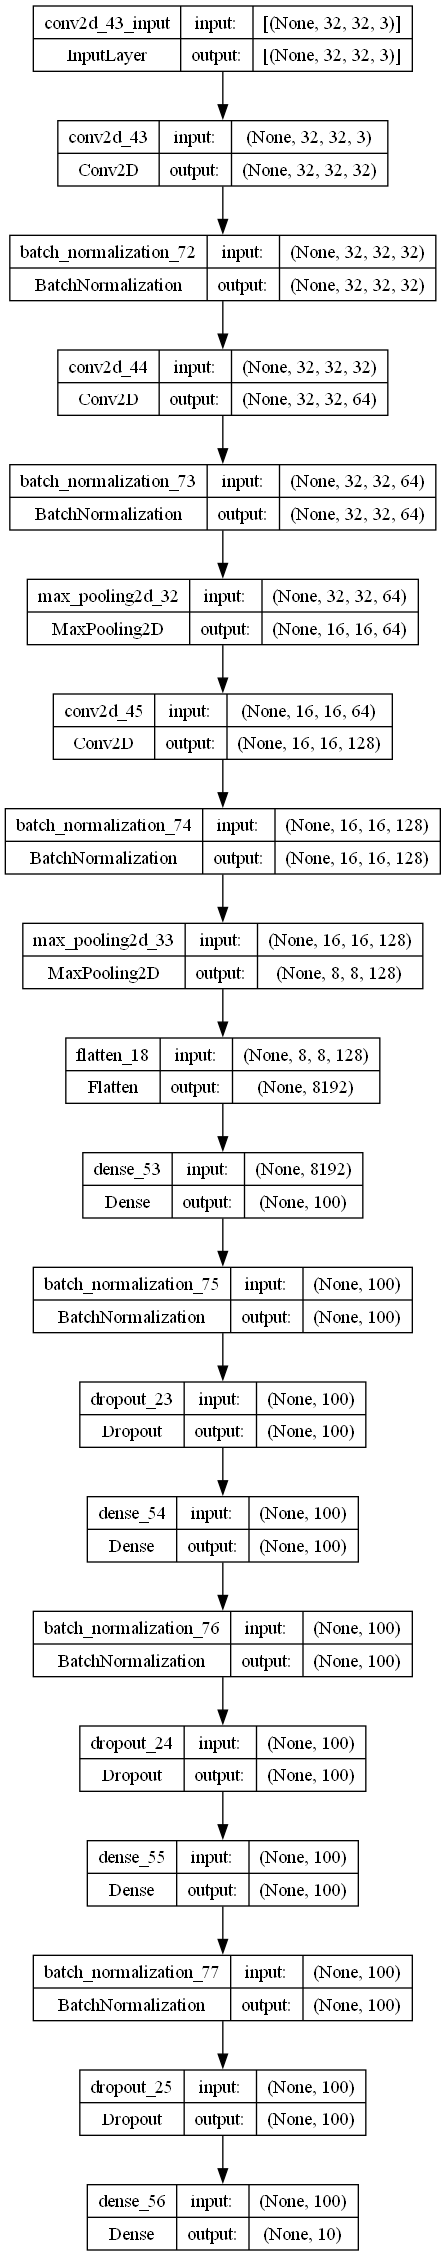

In [94]:
tf.keras.utils.plot_model(final_model, '2conv64_1dense100_1.png', show_shapes=True)

In [95]:
final_model.compile(optimizer = keras.optimizers.SGD(), loss=keras.losses.CategoricalCrossentropy())
final_model.fit(datagen.flow(dg_x_train, dg_y_train, batch_size=16), epochs=100, callbacks=final_callbacks, validation_data=val_datagen.flow(dg_x_val, dg_y_val))

Epoch 1/100
2188/2188 [==============================] - 121s 55ms/step - loss: 1.9332 - val_loss: 1.5792
Epoch 2/100
2188/2188 [==============================] - 118s 54ms/step - loss: 1.5597 - val_loss: 1.6129
Epoch 3/100
2188/2188 [==============================] - 110s 50ms/step - loss: 1.4020 - val_loss: 1.2673
Epoch 4/100
2188/2188 [==============================] - 110s 50ms/step - loss: 1.3121 - val_loss: 1.1264
Epoch 5/100
2188/2188 [==============================] - 110s 50ms/step - loss: 1.2501 - val_loss: 1.0616
Epoch 6/100
2188/2188 [==============================] - 110s 50ms/step - loss: 1.1934 - val_loss: 1.0525
Epoch 7/100
2188/2188 [==============================] - 111s 51ms/step - loss: 1.1503 - val_loss: 0.9910
Epoch 8/100
2188/2188 [==============================] - 110s 50ms/step - loss: 1.1167 - val_loss: 1.2785
Epoch 9/100
2188/2188 [==============================] - 110s 50ms/step - loss: 1.0866 - val_loss: 0.9232
Epoch 10/100
2188/2188 [======================

Момент истины: проверьте, какого качества достигла ваша сеть.

In [96]:
from sklearn.metrics import accuracy_score

predict_x=final_model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")

313/313 [==============================] - 6s 20ms/step

 Test_acc = 0.8146
Это победа!


### <s>Ощущения</s> Результаты экспериментов:

- Нарушил правило чистого эксперимента, хотелось уже побыстрее закончить. Думаю можно сделать модель и попроще с аналогичным результатом.
- Ощутил мощь Dropout для борьбы с переобучением
- Ощутил ускорение обучения от MaxPool2D
- MaxPool2D после первого сверточного слоя с 32 фильтрами ухудшает качество модели.
- Уже под конец понял, что нужно задавать больший patience, я задал 10, с patience равным 5 модель может остановиться раньше чем могла бы, особенно с использованием Dropout.

Конкретные результаты:
- Два сверточных слоя по 64 фильтра + 1 полносвязный на 100, patience равный 5, 27 эпох
 Test_acc = 0.6902
- Два сверточных слоя по 30 фильтров + 2 полносвязных на 100, patience равный 5, 32 эпохи
 Test_acc = 0.7163
- Два сверточных слоя по 32 и 64 фильтра + 2 полносвязных на 100, patience равный 5, 29 эпох
 Test_acc = 0.7217
- Три сверточных слоя 32, 64, 128, два последних с MaxPool2D. Два полносвязных слоя по 100 элементов с DropOut 0.3 после каждого, patience равный 5
  Test_acc = 0.7943
- Три сверточных слоя 32, 64, 128, все с MaxPool2D. Два полносвязных слоя по 150 элементов с DropOut 0.4 после каждого, patience равный 5
  Test_acc = 0.7335
- Три сверточных слоя 32, 64, 128, все с MaxPool2D. Два полносвязных слоя по 150 элементов с DropOut 0.3 после каждого, patience равный 5
 Test_acc = 0.7259
- Три сверточных слоя 32, 64, 128, два последних с MaxPool2D. Два полносвязных слоя по 150 элементов с DropOut 0.3 после каждого, patience равный 5
 Test_acc = 0.7852
- Три сверточных слоя 32, 64, 128, два последних с MaxPool2D. Три полносвязных слоя по 100 элементов с DropOut 0.25 после каждого, , patience равный 10, 68 эпох
Test_acc = 0.8146
Это победа!